# Interacting Size-Consistent Quantum Krylov Diagonalization

Test whether a **symmetrically dressed, N² product Krylov basis** yields a **size-consistent** ansatz for interacting bipartite systems.

## Hamiltonian partition

$$H_\text{tot} = H_a + H_b + H_{ab}$$

**Dressed operators** (half the interaction on each fragment):

$$H_A = H_a + \tfrac{1}{2}H_{ab}, \qquad H_B = H_b + \tfrac{1}{2}H_{ab}, \qquad H_A + H_B = H_\text{tot}$$

## Three procedures

| # | Name | Krylov size | Description |
|---|---|---|---|
| **1 — Novel** | Dressed product | **N²** | $|\Phi_{i,j}\rangle = e^{-ii\delta t H_A}e^{-ij\delta t H_B}|\text{ref}\rangle$; project with $H_\text{tot}$ |
| **2 — Separate fragments** | **N** each | KQD on $H_a$, $H_b$, $H_\text{tot}$ independently; $\Delta_\text{int}^{(1)} = |E_\text{tot} - (E_a + E_b)|$ |
| **3 — Non-interacting dimer** | **N** each | KQD on $H_a\otimes I + I\otimes H_b$ and $H_\text{tot}$; $\Delta_\text{int}^{(2)} = |E_\text{tot} - E_\text{dimer}|$ |

## Metrics (tracked vs Krylov dimension $N$)

- **GS error:** $|E_\text{method} - E_\text{exact}(H_\text{tot})|$
- **Size-consistency error:** $|E_\text{method} - [E_\text{exact}(a) + E_\text{exact}(b)]|$
- **Interaction gap (baselines):** $\Delta_\text{int}^{(1)}$, $\Delta_\text{int}^{(2)}$ as above

**Interaction strength** is read from molecular separation $R$ (not a tunable $\lambda$).

**System:** two H₂, STO-3G, $R \in \{1000, 100, 10, 1.1\}$ Å. Joint Hilbert dim = 16.


In [1]:
# ── Imports and output directory ─────────────────────────────────────────────
# This notebook:
#   1. Builds real two-H2 Hamiltonians at separation R via PySCF + Qiskit Nature
#   2. Partitions H_tot = H_a + H_b + H_ab by Pauli-term qubit support
#   3. Runs three KQD procedures and sweeps Krylov dimension N
#   4. Plots size-consistency error and ground-state convergence vs N and R

import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import scipy.linalg as la

from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.formats.molecule_info import MoleculeInfo
from qiskit_nature.second_q.mappers import ParityMapper
from qiskit_nature.second_q.circuit.library import HartreeFock

FIG_DIR = 'output/krylov_interacting_sc_figures'
os.makedirs(FIG_DIR, exist_ok=True)
warnings.filterwarnings('ignore')

# Physical constants / sweep grids used throughout
BASIS = 'sto-3g'
BOND = 0.735          # H2 bond length [Angstrom]
R_LIST = [1000.0, 100.0, 10.0, 1.1]   # centre-to-centre separation [Angstrom]
N_LIST = [2, 3, 4]    # per-fragment Krylov order (N=4 -> N^2=16 = full joint space)
SVD_THRESH = 1e-10    # regularised GEVP threshold (same as krylov_h2_exact_sc notebooks)

print('Notebook ready | figures ->', FIG_DIR)
print(f'R sweep: {R_LIST}  |  N sweep: {N_LIST}')


Notebook ready | figures -> output/krylov_interacting_sc_figures
R sweep: [1000.0, 100.0, 10.0, 1.1]  |  N sweep: [2, 3, 4]


In [2]:
# ── Core KQD helpers (exact evolution, no Trotter) ───────────────────────────
# These are shared by all three procedures. Each builds states |psi_k> = U^k |ref>
# with U = expm(-i H dt), then solves the generalised eigenvalue problem
#   H_tilde c = E S_tilde c
# after discarding near-zero eigenvalues of S_tilde.


def build_krylov_states(H_matrix, psi_ref, krylov_dim, dt):
    """Build Krylov states |psi_k> = exp(-i H k dt) |ref> for k = 0..krylov_dim-1.

    H_matrix : operator on the relevant Hilbert space (monomer dim 4 or joint dim 16)
    psi_ref  : reference statevector on the SAME space
    krylov_dim : N (number of states in this Krylov chain)
    dt       : time step (typically pi / ||H||_2)

    Optimisation: one matrix exponential U = expm(-i H dt), then repeated matvecs.
    """
    U = la.expm(-1j * H_matrix * dt)
    states = [psi_ref.copy().astype(complex)]
    for _ in range(1, krylov_dim):
        states.append(U @ states[-1])
    return states


def build_krylov_matrices(H_matrix, states):
    """Assemble overlap S_ij = <i|j> and projected Hamiltonian H_ij = <i|H|j>."""
    Psi = np.column_stack(states)
    S = Psi.conj().T @ Psi
    Ht = Psi.conj().T @ (H_matrix @ Psi)
    return S, Ht


def solve_gen_eig(H_tilde, S_tilde, threshold=SVD_THRESH):
    """Regularised GEVP: discard S eigenvalues below threshold, solve reduced problem."""
    s_vals, s_vecs = sp.linalg.eigh(S_tilde)
    s_vecs = s_vecs.T
    good = np.array([v for val, v in zip(s_vals, s_vecs) if val > threshold])
    if len(good) == 0:
        return np.nan, 0
    H_reg = good.conj() @ H_tilde @ good.T
    S_reg = good.conj() @ S_tilde @ good.T
    e_gs = float(sp.linalg.eigh(H_reg, S_reg)[0][0].real)
    return e_gs, len(good)


def run_kqd_exact(H_matrix, psi_ref, krylov_dim, dt, nuclear_rep, threshold=SVD_THRESH):
    """Standard KQD: returns electronic GS, total GS, effective dimension, S eigenvalues."""
    states = build_krylov_states(H_matrix, psi_ref, krylov_dim, dt)
    S, Ht = build_krylov_matrices(H_matrix, states)
    gs_elec, eff_dim = solve_gen_eig(Ht, S, threshold)
    s_evals = np.sort(np.linalg.eigvalsh(S).real)[::-1]
    return {
        'gs_elec': gs_elec,
        'gs_total': gs_elec + nuclear_rep,
        'eff_dim': eff_dim,
        'S': S,
        's_evals': s_evals,
        's_min': float(s_evals[-1]),
    }


def compute_dt(H_matrix):
    """Default time step dt = pi / ||H||_2 (spectral norm)."""
    return np.pi / float(np.linalg.norm(H_matrix, ord=2))


print('Core KQD helpers defined.')


Core KQD helpers defined.


## Step 1: Molecular Hamiltonian build and partition

Build:
- **Monomer** $H_a = H_b$ (single H₂, STO-3G, dim 4)
- **Dimer** $H_\text{tot}$ at separation $R$ (two H₂, dim 16)
- **Partition** $H_\text{tot} = H_a + H_b + H_{ab}$ by Pauli-term qubit support
- **Dressed** $H_A$, $H_B$ for the novel procedure

At $R = 1000$ Å, $H_{ab} \approx 0$ and $E_\text{exact}(H_\text{tot}) \approx 2 E_\text{exact}(\text{monomer})$.


In [3]:
# ── Step 1: build monomer, dimer at R, partition, dressed operators ──────────

def _pauli_support(label):
    """Active qubit indices for a Pauli string (Qiskit little-endian: rightmost = qubit 0)."""
    n = len(label)
    return {n - 1 - j for j, ch in enumerate(label) if ch != 'I'}


def build_h2_monomer(basis=BASIS, bond=BOND):
    """Single H2: returns dense H_a matrix, HF ref, nuclear rep, exact GS energies."""
    half = bond / 2.0
    mol = MoleculeInfo(symbols=['H', 'H'],
                       coords=[(0., 0., -half), (0., 0., half)],
                       charge=0, multiplicity=1)
    problem = PySCFDriver.from_molecule(mol, basis=basis).run()
    E_nuc = problem.nuclear_repulsion_energy
    mapper = ParityMapper(num_particles=problem.num_particles)
    H_op = mapper.map(problem.hamiltonian.second_q_op())
    H = H_op.to_matrix().astype(complex)
    gs_elec = float(np.linalg.eigvalsh(H)[0].real)
    hf = HartreeFock(num_spatial_orbitals=problem.num_spatial_orbitals,
                     num_particles=problem.num_particles, qubit_mapper=mapper)
    ref = np.array(Statevector(hf.decompose()).data, dtype=complex)
    return {'H': H, 'H_op': H_op, 'ref': ref, 'E_nuc': E_nuc,
            'n_qubits': H_op.num_qubits, 'gs_elec': gs_elec,
            'gs_total': gs_elec + E_nuc, 'mapper': mapper, 'problem': problem}


def build_h2_dimer(R_angstrom, basis=BASIS, bond=BOND):
    """Two H2 molecules centred at z = +/- R/2 along the z-axis.

    Returns joint H_tot (dim 16), SparsePauliOp, dimer HF reference, exact GS.
  At large R the intermolecular terms in H_ab vanish.
    """
    b2 = bond / 2.0
    zA = -R_angstrom / 2.0
    zB = +R_angstrom / 2.0
    mol = MoleculeInfo(
        symbols=['H', 'H', 'H', 'H'],
        coords=[
            (0., 0., zA - b2), (0., 0., zA + b2),   # molecule A (qubits 0,1)
            (0., 0., zB - b2), (0., 0., zB + b2),   # molecule B (qubits 2,3)
        ],
        charge=0, multiplicity=1,
    )
    problem = PySCFDriver.from_molecule(mol, basis=basis).run()
    E_nuc = problem.nuclear_repulsion_energy
    mapper = ParityMapper(num_particles=problem.num_particles)
    H_op = mapper.map(problem.hamiltonian.second_q_op())
    H = H_op.to_matrix().astype(complex)
    gs_elec = float(np.linalg.eigvalsh(H)[0].real)
    hf = HartreeFock(num_spatial_orbitals=problem.num_spatial_orbitals,
                     num_particles=problem.num_particles, qubit_mapper=mapper)
    ref = np.array(Statevector(hf.decompose()).data, dtype=complex)
    return {'H': H, 'H_op': H_op, 'ref': ref, 'E_nuc': E_nuc,
            'n_qubits': H_op.num_qubits, 'gs_elec': gs_elec,
            'gs_total': gs_elec + E_nuc, 'R': R_angstrom}


def partition_hamiltonian(H_op, qubits_a, qubits_b):
    """Split SparsePauliOp into H_a, H_b, H_ab by qubit support.

    Terms acting only on qubits_a -> H_a; only on qubits_b -> H_b; mixed -> H_ab.
    Returns dense matrices and term counts.
    """
    qa, qb = set(qubits_a), set(qubits_b)
    pa, pb, pab = [], [], []
    ca, cb, cab = [], [], []
    labels_ab_sample = []
    for pauli, coeff in zip(H_op.paulis, H_op.coeffs):
        label = pauli.to_label()
        sup = _pauli_support(label)
        c = complex(coeff)
        if sup <= qa:
            pa.append(label); ca.append(c)
        elif sup <= qb:
            pb.append(label); cb.append(c)
        else:
            pab.append(label); cab.append(c)
            if len(labels_ab_sample) < 5:
                labels_ab_sample.append((label, c))
    def to_mat(labels, coeffs):
        if not labels:
            n = 2 ** H_op.num_qubits
            return np.zeros((n, n), dtype=complex)
        return SparsePauliOp.from_list(list(zip(labels, coeffs))).to_matrix().astype(complex)
    H_a = to_mat(pa, ca)
    H_b = to_mat(pb, cb)
    H_ab = to_mat(pab, cab)
    H_tot = H_op.to_matrix().astype(complex)
    residual = np.linalg.norm(H_tot - H_a - H_b - H_ab, ord=2)
    return {
        'H_a': H_a, 'H_b': H_b, 'H_ab': H_ab, 'H_tot': H_tot,
        'n_a': len(pa), 'n_b': len(pb), 'n_ab': len(pab),
        'residual': residual, 'ab_sample': labels_ab_sample,
    }


def build_dressed_operators(H_a, H_b, H_ab):
    """H_A = H_a + 1/2 H_ab,  H_B = H_b + 1/2 H_ab.  Verify H_A + H_B = H_tot."""
    H_A = H_a + 0.5 * H_ab
    H_B = H_b + 0.5 * H_ab
    return H_A, H_B


def build_noninteracting_dimer(h_mono, ref_mono):
    """H_a (x) I + I (x) H_a for Baseline 3 — tensor product on joint space (dim 16).

    Uses the monomer Hamiltonian twice (identical fragments A and B).
    Reference: |ref_A> (x) |ref_B>.
    """
    n = h_mono.shape[0]
    I = np.eye(n, dtype=complex)
    H_dimer = np.kron(h_mono, I) + np.kron(I, h_mono)
    ref_dimer = np.kron(ref_mono, ref_mono)
    return H_dimer, ref_dimer


# ── Build monomer (shared by all R) ───────────────────────────────────────────
print('Building H2 monomer (STO-3G)...')
mono = build_h2_monomer()
print(f'  Monomer: {mono["n_qubits"]} qubits, dim {mono["H"].shape[0]}, '
      f'exact GS = {mono["gs_total"]:.8f} Ha')

# Qubit assignment: after ParityMapper 2Q reduction on 4-electron dimer, use {0,1}=A, {2,3}=B
QUBITS_A = [0, 1]
QUBITS_B = [2, 3]

# ── Build dimer at each separation R ──────────────────────────────────────────
systems = {}
build_rows = []
for R in R_LIST:
    try:
        dim = build_h2_dimer(R)
    except Exception as exc:
        fallback = 2.0 if R < 2.0 else None
        if fallback is not None:
            print(f'  WARNING: R={R} A failed ({exc}); trying R={fallback} A')
            try:
                dim = build_h2_dimer(fallback)
                R = fallback
            except Exception as exc2:
                print(f'  ERROR: fallback also failed ({exc2}); skipping')
                continue
        else:
            print(f'  WARNING: R={R} A failed ({exc}); skipping')
            continue
    part = partition_hamiltonian(dim['H_op'], QUBITS_A, QUBITS_B)
    H_A, H_B = build_dressed_operators(part['H_a'], part['H_b'], part['H_ab'])
    dress_resid = np.linalg.norm(H_A + H_B - part['H_tot'], ord=2)
    H_dimer, ref_dimer = build_noninteracting_dimer(mono['H'], mono['ref'])
    E_exact_sum = 2.0 * mono['gs_total']   # E_exact(a) + E_exact(b) for identical monomers
    delta_exact = dim['gs_total'] - E_exact_sum
    systems[R] = {
        **dim, **part,
        'H_A': H_A, 'H_B': H_B,
        'H_dimer': H_dimer, 'ref_dimer': ref_dimer,
        'E_exact_sum': E_exact_sum,
        'delta_exact': delta_exact,
        'dress_residual': dress_resid,
        'dt_tot': compute_dt(part['H_tot']),
        'dt_mono': compute_dt(mono['H']),
    }
    build_rows.append({
        'R': R, 'E_exact_tot': dim['gs_total'], 'E_exact_sum': E_exact_sum,
        'delta_exact': delta_exact,
        'norm_H_ab': float(np.linalg.norm(part['H_ab'], ord=2)),
        'n_terms_ab': part['n_ab'], 'partition_residual': part['residual'],
        'dress_residual': dress_resid,
    })
    print(f'R={R:7.1f} A | GS={dim["gs_total"]:.8f} | Delta_exact={delta_exact:.2e} | '
          f'||H_ab||={np.linalg.norm(part["H_ab"], ord=2):.2e} | '
          f'H_ab terms={part["n_ab"]} | partition_res={part["residual"]:.2e}')

df_build = pd.DataFrame(build_rows)
df_build.to_csv(f'{FIG_DIR}/step01_build.csv', index=False)
print(f'Built {len(systems)} dimer systems -> {FIG_DIR}/step01_build.csv')


Building H2 monomer (STO-3G)...
  Monomer: 2 qubits, dim 4, exact GS = -1.13730604 Ha


R= 1000.0 A | GS=-2.27461207 | Delta_exact=1.33e-14 | ||H_ab||=2.18e+00 | H_ab terms=55 | partition_res=1.55e-15


R=  100.0 A | GS=-2.27461207 | Delta_exact=2.04e-12 | ||H_ab||=2.19e+00 | H_ab terms=55 | partition_res=1.33e-15


R=   10.0 A | GS=-2.27461195 | Delta_exact=1.24e-07 | ||H_ab||=2.44e+00 | H_ab terms=248 | partition_res=1.11e-15


R=    1.1 A | GS=-1.62751587 | Delta_exact=6.47e-01 | ||H_ab||=5.02e+00 | H_ab terms=155 | partition_res=1.78e-15
Built 4 dimer systems -> output/krylov_interacting_sc_figures/step01_build.csv


## Step 2: Three KQD procedures

All procedures target the joint ground-state energy $E(H_\text{tot})$. Only Procedure 1 uses an **N²** basis; baselines use **N**.


In [4]:
# ── Procedure 1 (NOVEL): dressed product Krylov basis, size N^2 ───────────────
# H_A = H_a + 1/2*H_ab,  H_B = H_b + 1/2*H_ab  (both on the joint 16-dim register)
# States: |Phi_ij> = U_A^i U_B^j |ref>  for i,j = 0..N-1  ->  N^2 vectors total
# Project with the FULL interacting H_tot and solve the GEVP.
# When H_ab = 0 the propagators commute and states factorise; when interacting they do not.


def build_product_states(H_A, H_B, ref, N, dt):
    """Construct N^2 product Krylov states on the joint Hilbert space."""
    ref = ref.astype(complex)
    U_A = la.expm(-1j * dt * H_A)
    U_B = la.expm(-1j * dt * H_B)
    # Precompute U_B^j |ref> for j = 0..N-1
    b_chain = [ref.copy()]
    for _ in range(1, N):
        b_chain.append(U_B @ b_chain[-1])
    # Precompute U_A^i
    a_chain = [np.eye(H_A.shape[0], dtype=complex)]
    for _ in range(1, N):
        a_chain.append(U_A @ a_chain[-1])
    states = []
    for i in range(N):
        for j in range(N):
            # |Phi_ij> = U_A^i U_B^j |ref>
            states.append(a_chain[i] @ b_chain[j])
    return states


def run_kqd_novel(sys, N, threshold=SVD_THRESH):
    """Procedure 1: N^2 dressed product basis projected with H_tot."""
    dt = sys['dt_tot']
    states = build_product_states(sys['H_A'], sys['H_B'], sys['ref'], N, dt)
    S, Ht = build_krylov_matrices(sys['H_tot'], states)
    gs_elec, eff_dim = solve_gen_eig(Ht, S, threshold)
    gs_total = gs_elec + sys['E_nuc']
    s_evals = np.sort(np.linalg.eigvalsh(S).real)[::-1]
    E_exact_tot = sys['gs_total']
    E_exact_sum = sys['E_exact_sum']
    return {
        'procedure': 'novel',
        'N': N, 'dim': N * N,
        'gs_total': gs_total,
        'gs_err': abs(gs_total - E_exact_tot),
        # SC error: deviation from sum of fragment exact energies
        'delta_sc': abs(gs_total - E_exact_sum),
        's_min': float(s_evals[-1]),
        'eff_dim': eff_dim,
        'S': S,
    }


print('Procedure 1 (novel, N^2) defined.')


Procedure 1 (novel, N^2) defined.


In [5]:
# ── Baseline 2: separate-fragment KQD, each at dimension N ─────────────────
# Three INDEPENDENT KQD runs:
#   (a) KQD(H_a, N) on monomer space (dim 4) with monomer HF ref
#   (b) KQD(H_b, N) on monomer space (dim 4) — same H_a for identical H2 fragments
#   (c) KQD(H_tot, N) on joint space (dim 16) with dimer HF ref
# Interaction gap: Delta_int^(1) = |E_tot - (E_a + E_b)|  (KQD energies)
# SC error for the joint run: |E_tot - (E_exact_a + E_exact_b)|


def run_baseline_separate(sys, mono, N, threshold=SVD_THRESH):
    dt_mono = sys['dt_mono']   # pi/||H_a||_2 on monomer space
    dt_tot = sys['dt_tot']     # pi/||H_tot||_2 on joint space
    # Fragment KQD on monomer (dim 4)
    r_a = run_kqd_exact(mono['H'], mono['ref'], N, dt_mono, mono['E_nuc'], threshold)
    r_b = run_kqd_exact(mono['H'], mono['ref'], N, dt_mono, mono['E_nuc'], threshold)
    # Joint KQD on full H_tot (dim 16)
    r_tot = run_kqd_exact(sys['H_tot'], sys['ref'], N, dt_tot, sys['E_nuc'], threshold)
    E_a, E_b, E_tot = r_a['gs_total'], r_b['gs_total'], r_tot['gs_total']
    E_exact_tot = sys['gs_total']
    E_exact_sum = sys['E_exact_sum']
    return {
        'procedure': 'baseline_separate',
        'N': N, 'dim': N,
        'E_a': E_a, 'E_b': E_b, 'gs_total': E_tot,
        'delta_int': abs(E_tot - (E_a + E_b)),
        'gs_err': abs(E_tot - E_exact_tot),
        'delta_sc': abs(E_tot - E_exact_sum),
        's_min': r_tot['s_min'],
        'eff_dim': r_tot['eff_dim'],
    }


print('Baseline 2 (separate fragments, N) defined.')


Baseline 2 (separate fragments, N) defined.


In [6]:
# ── Baseline 3: non-interacting dimer vs interacting total, each at N ────────
# Two KQD runs on the JOINT space (dim 16):
#   (a) KQD(H_a⊗I + I⊗H_a, N)  — non-interacting dimer (no H_ab)
#   (b) KQD(H_tot, N)          — full interacting Hamiltonian
# Interaction gap: Delta_int^(2) = |E_tot - E_dimer|
# SC error of dimer run: |E_dimer - (E_exact_a + E_exact_b)|


def run_baseline_dimer(sys, N, threshold=SVD_THRESH):
    dt = sys['dt_tot']
    r_dimer = run_kqd_exact(sys['H_dimer'], sys['ref_dimer'], N, dt, 2 * mono['E_nuc'], threshold)
    r_tot = run_kqd_exact(sys['H_tot'], sys['ref'], N, dt, sys['E_nuc'], threshold)
    E_dimer, E_tot = r_dimer['gs_total'], r_tot['gs_total']
    E_exact_tot = sys['gs_total']
    E_exact_sum = sys['E_exact_sum']
    return {
        'procedure': 'baseline_dimer',
        'N': N, 'dim': N,
        'E_dimer': E_dimer, 'gs_total': E_tot,
        'delta_int': abs(E_tot - E_dimer),
        'gs_err': abs(E_tot - E_exact_tot),
        'delta_sc': abs(E_dimer - E_exact_sum),
        's_min': r_tot['s_min'],
        'eff_dim': r_tot['eff_dim'],
    }


print('Baseline 3 (non-interacting dimer, N) defined.')


Baseline 3 (non-interacting dimer, N) defined.


## Step 3: Sweep Krylov dimension N at each separation R

For each $(R, N)$ run all three procedures and record GS error, size-consistency error, and interaction gaps.


In [7]:
# ── Step 3: main experiment sweep ────────────────────────────────────────────

def sweep_all(systems, mono, N_list=N_LIST, threshold=SVD_THRESH):
    """Run all three procedures for every (R, N) and return a flat DataFrame."""
    rows = []
    for R, sys in sorted(systems.items()):
        for N in N_list:
            # Procedure 1: novel (N^2 basis)
            rn = run_kqd_novel(sys, N, threshold)
            rows.append({
                'R': R, 'N': N, 'procedure': 'novel', 'basis_dim': N * N,
                'gs_total': rn['gs_total'], 'gs_err': rn['gs_err'],
                'delta_sc': rn['delta_sc'], 'delta_int': np.nan,
                's_min': rn['s_min'], 'eff_dim': rn['eff_dim'],
                'E_exact_tot': sys['gs_total'], 'E_exact_sum': sys['E_exact_sum'],
                'delta_exact': sys['delta_exact'],
            })
            # Baseline 2: separate fragments
            b2 = run_baseline_separate(sys, mono, N, threshold)
            rows.append({
                'R': R, 'N': N, 'procedure': 'baseline_separate', 'basis_dim': N,
                'gs_total': b2['gs_total'], 'gs_err': b2['gs_err'],
                'delta_sc': b2['delta_sc'], 'delta_int': b2['delta_int'],
                's_min': b2['s_min'], 'eff_dim': b2['eff_dim'],
                'E_a': b2['E_a'], 'E_b': b2['E_b'],
                'E_exact_tot': sys['gs_total'], 'E_exact_sum': sys['E_exact_sum'],
                'delta_exact': sys['delta_exact'],
            })
            # Baseline 3: non-interacting dimer
            b3 = run_baseline_dimer(sys, N, threshold)
            rows.append({
                'R': R, 'N': N, 'procedure': 'baseline_dimer', 'basis_dim': N,
                'gs_total': b3['gs_total'], 'gs_err': b3['gs_err'],
                'delta_sc': b3['delta_sc'], 'delta_int': b3['delta_int'],
                's_min': b3['s_min'], 'eff_dim': b3['eff_dim'],
                'E_dimer': b3['E_dimer'],
                'E_exact_tot': sys['gs_total'], 'E_exact_sum': sys['E_exact_sum'],
                'delta_exact': sys['delta_exact'],
            })
    return pd.DataFrame(rows)


print('Running sweep over R and N...')
df_sweep = sweep_all(systems, mono)
df_sweep.to_csv(f'{FIG_DIR}/step02_sweep.csv', index=False)
print(f'Sweep complete: {len(df_sweep)} rows -> {FIG_DIR}/step02_sweep.csv')
print(df_sweep.groupby(['procedure', 'R'])['gs_err'].min().to_string())


Running sweep over R and N...


Sweep complete: 36 rows -> output/krylov_interacting_sc_figures/step02_sweep.csv
procedure          R     
baseline_dimer     1.1       1.433370e-03
                   10.0      7.567280e-13
                   100.0     1.776357e-15
                   1000.0    1.776357e-15
baseline_separate  1.1       1.433370e-03
                   10.0      7.567280e-13
                   100.0     1.776357e-15
                   1000.0    1.776357e-15
novel              1.1       1.866074e-04
                   10.0      4.234140e-09
                   100.0     2.220446e-15
                   1000.0    1.776357e-15


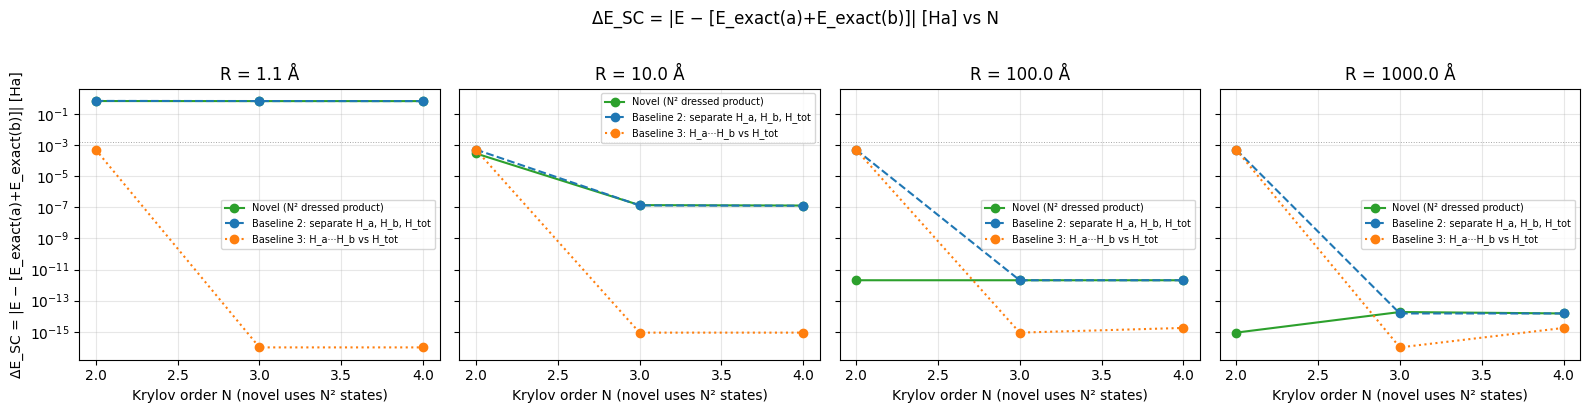

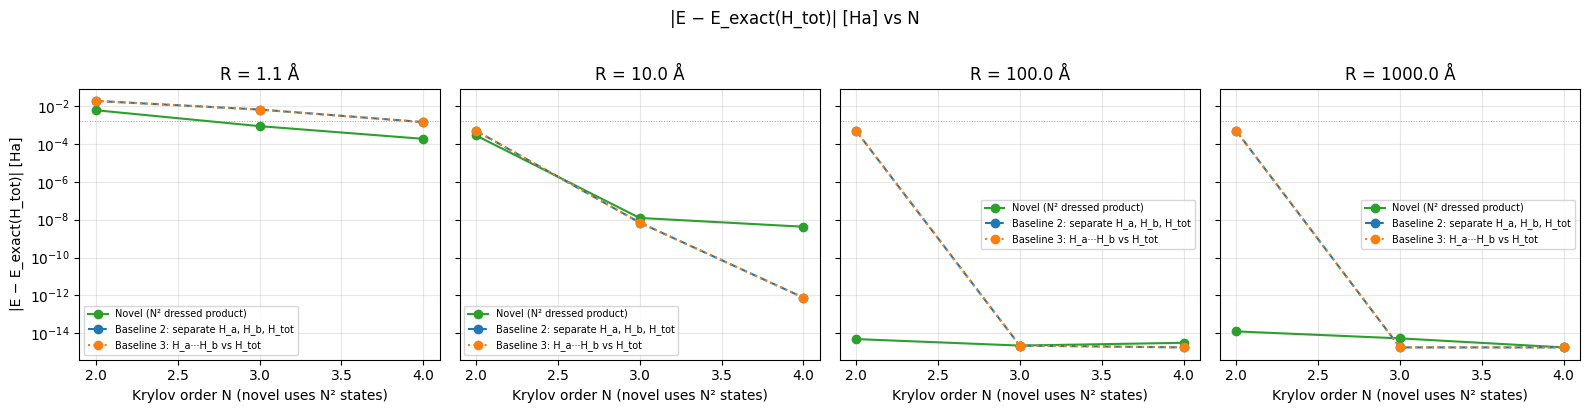

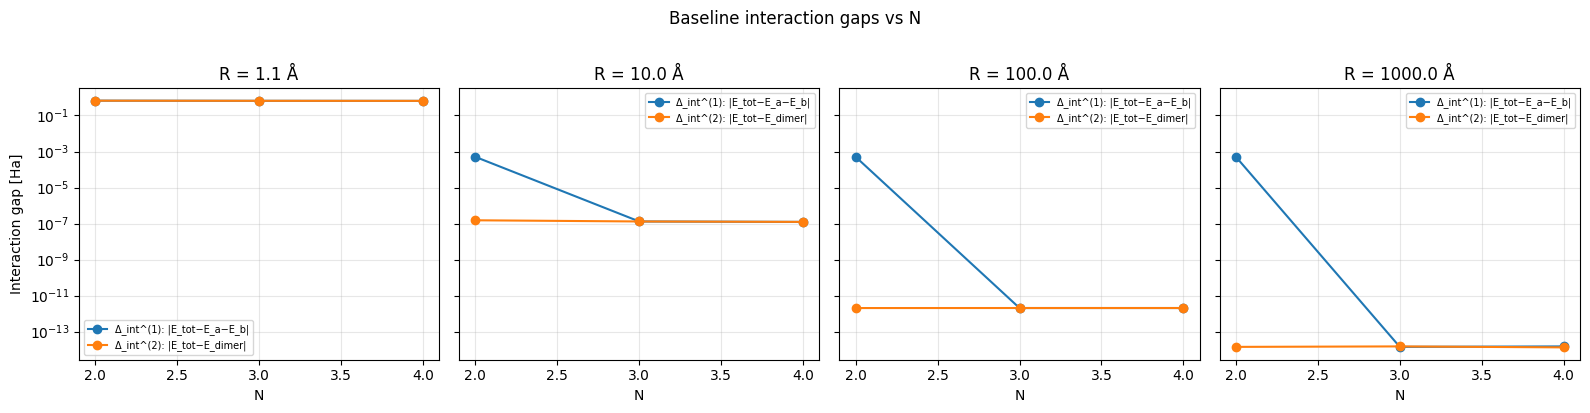

In [8]:
# ── Step 3 plots: SC error, GS error, interaction gaps vs N ─────────────────

PROC_STYLE = {
    'novel': ('-', 'C2', 'Novel (N² dressed product)'),
    'baseline_separate': ('--', 'C0', 'Baseline 2: separate H_a, H_b, H_tot'),
    'baseline_dimer': (':', 'C1', 'Baseline 3: H_a···H_b vs H_tot'),
}

def _plot_metric_vs_N(df, metric, ylabel, filename, logy=True):
    fig, axes = plt.subplots(1, len(systems), figsize=(4 * len(systems), 4), sharey=True)
    if len(systems) == 1:
        axes = [axes]
    for ax, R in zip(axes, sorted(systems.keys())):
        sub = df[df['R'] == R]
        for proc, (ls, c, lbl) in PROC_STYLE.items():
            s = sub[sub['procedure'] == proc].sort_values('N')
            y = s[metric].values
            if logy:
                y = np.maximum(y, 1e-16)
                ax.semilogy(s['N'], y, ls, color=c, marker='o', label=lbl)
            else:
                ax.plot(s['N'], y, ls, color=c, marker='o', label=lbl)
        ax.axhline(1.6e-3, color='gray', ls=':', lw=0.7, alpha=0.7)
        ax.set_xlabel('Krylov order N (novel uses N² states)')
        ax.set_title(f'R = {R:.1f} Å')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)
    axes[0].set_ylabel(ylabel)
    fig.suptitle(ylabel + ' vs N', y=1.02)
    fig.tight_layout()
    fig.savefig(f'{FIG_DIR}/{filename}', dpi=150, bbox_inches='tight')
    plt.show()

# Main hypothesis figure: size-consistency error vs N
_plot_metric_vs_N(df_sweep, 'delta_sc', 'ΔE_SC = |E − [E_exact(a)+E_exact(b)]| [Ha]',
                  'sc_error_vs_N.png')

# Ground-state convergence
_plot_metric_vs_N(df_sweep, 'gs_err', '|E − E_exact(H_tot)| [Ha]',
                  'gs_error_vs_N.png')

# Interaction gaps for baselines only
fig, axes = plt.subplots(1, len(systems), figsize=(4 * len(systems), 4), sharey=True)
if len(systems) == 1:
    axes = [axes]
for ax, R in zip(axes, sorted(systems.keys())):
    sub = df_sweep[df_sweep['R'] == R]
    for proc, lbl, c in [('baseline_separate', 'Δ_int^(1): |E_tot−E_a−E_b|', 'C0'),
                         ('baseline_dimer', 'Δ_int^(2): |E_tot−E_dimer|', 'C1')]:
        s = sub[sub['procedure'] == proc].sort_values('N')
        ax.semilogy(s['N'], np.maximum(s['delta_int'], 1e-16), 'o-', color=c, label=lbl)
    ax.set_xlabel('N'); ax.set_title(f'R = {R:.1f} Å'); ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)
axes[0].set_ylabel('Interaction gap [Ha]')
fig.suptitle('Baseline interaction gaps vs N', y=1.02)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/delta_int_vs_N.png', dpi=150, bbox_inches='tight')
plt.show()


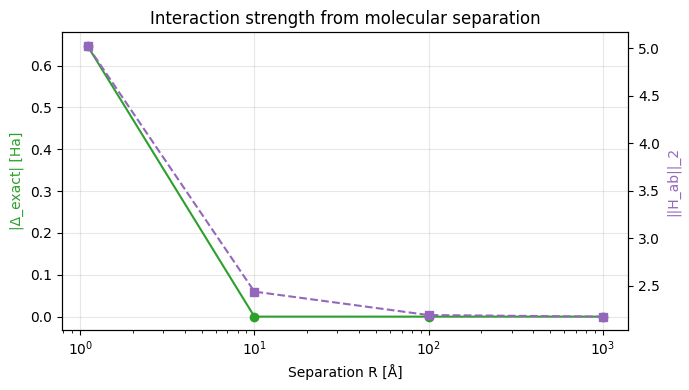

S_novel heatmaps saved (N=3) for each R


In [9]:
# ── Interaction strength vs R; optional S_novel heatmaps at N=3 ─────────────

# Physical interaction read from exact diagonalization (not a tunable lambda)
fig, ax1 = plt.subplots(figsize=(7, 4))
Rs = sorted(systems.keys())
delta_ex = [systems[R]['delta_exact'] for R in Rs]
norm_ab = [float(np.linalg.norm(systems[R]['H_ab'], ord=2)) for R in Rs]
ax1.semilogx(Rs, np.abs(delta_ex), 'o-', color='C2', label='|Δ_exact| = |E_tot − 2E_mono|')
ax1.set_xlabel('Separation R [Å]'); ax1.set_ylabel('|Δ_exact| [Ha]', color='C2')
ax2 = ax1.twinx()
ax2.semilogx(Rs, norm_ab, 's--', color='C4', label='||H_ab||_2')
ax2.set_ylabel('||H_ab||_2', color='C4')
ax1.set_title('Interaction strength from molecular separation')
ax1.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/interaction_vs_R.png', dpi=150, bbox_inches='tight')
plt.show()

# Overlap matrix heatmaps for novel procedure at N=3 (9x9) — shows structure vs R
N_heat = 3
for R in sorted(systems.keys()):
    rn = run_kqd_novel(systems[R], N_heat)
    S = np.abs(rn['S'])
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(S, origin='lower', aspect='auto')
    plt.colorbar(im, ax=ax, label='|S_ij|')
    ax.set_xlabel('j'); ax.set_ylabel('i')
    ax.set_title(f'Novel overlap |S| at N={N_heat}, R={R:.1f} Å')
    fig.tight_layout()
    fig.savefig(f'{FIG_DIR}/S_novel_heatmap_R{int(R)}.png', dpi=150, bbox_inches='tight')
    plt.close()
print(f'S_novel heatmaps saved (N={N_heat}) for each R')


## Step 3b: Close-contact focus ($R = 1.1$ Å) — interaction Hamiltonian and dressed split

At **$R = 1.1$ Å** the two H₂ molecules are in close contact; $H_{ab}$ is large ($\|H_{ab}\|_2 \approx 5$ Ha).

**Schematic 2×2 block layout** (fragment $A$ vs fragment $B$):

$$H_\text{tot} \;\approx\; \begin{pmatrix} H_a & H_{ab} \\ H_{ab} & H_b \end{pmatrix} = \underbrace{\begin{pmatrix} H_a & \tfrac{1}{2}H_{ab} \\ \tfrac{1}{2}H_{ab} & 0 \end{pmatrix}}_{H_A} + \underbrace{\begin{pmatrix} 0 & \tfrac{1}{2}H_{ab} \\ \tfrac{1}{2}H_{ab} & H_b \end{pmatrix}}_{H_B}$$

On the full $16\times16$ matrix we verify this **algebraically** ($H_A + H_B = H_\text{tot}$) and inspect **where** $H_a$, $H_b$, and $H_{ab}$ have weight in the $4\times4$ grid of $4\times4$ blocks (one block per $(i_B, j_B)$ pair of monomer-B basis indices).

R = 1.1 Å  |  E_exact(tot) = -1.62751587 Ha
  E_exact(a)+E_exact(b) = -2.27461207 Ha
  Delta_exact (interaction shift) = 0.647096 Ha

[Operator norms]
  H_a                           ||M||_2 =   2.298607  ||M||_F =  14.871263
  H_b                           ||M||_2 =   1.648475  ||M||_F =   9.767667
  H_ab                          ||M||_2 =   5.023194  ||M||_F =  11.815892
  H_A = H_a + 1/2 H_ab          ||M||_2 =   3.387091  ||M||_F =  16.001822
  H_B = H_b + 1/2 H_ab          ||M||_2 =   3.576919  ||M||_F =  11.415391
  H_tot                         ||M||_2 =   5.767775  ||M||_F =  21.358303

[Exact partition]  ||H_tot - H_a - H_b - H_ab||_F = 5.93e-15
[Dressing sum]     ||H_tot - H_A - H_B||_F           = 6.06e-15
[Element-wise max] |H_tot - H_A - H_B|_max           = 2.00e-15
  -> (H_a, H_ab; H_ab, H_b) = (H_a, H_ab/2; H_ab/2, 0) + (0, H_ab/2; H_ab/2, H_b) exactly.

[H_ab] 155 cross-fragment Pauli terms. First few:
    IIIZXX  coeff = +0.010750+0.000000j
    IIIXXZ  coeff = -0.0277

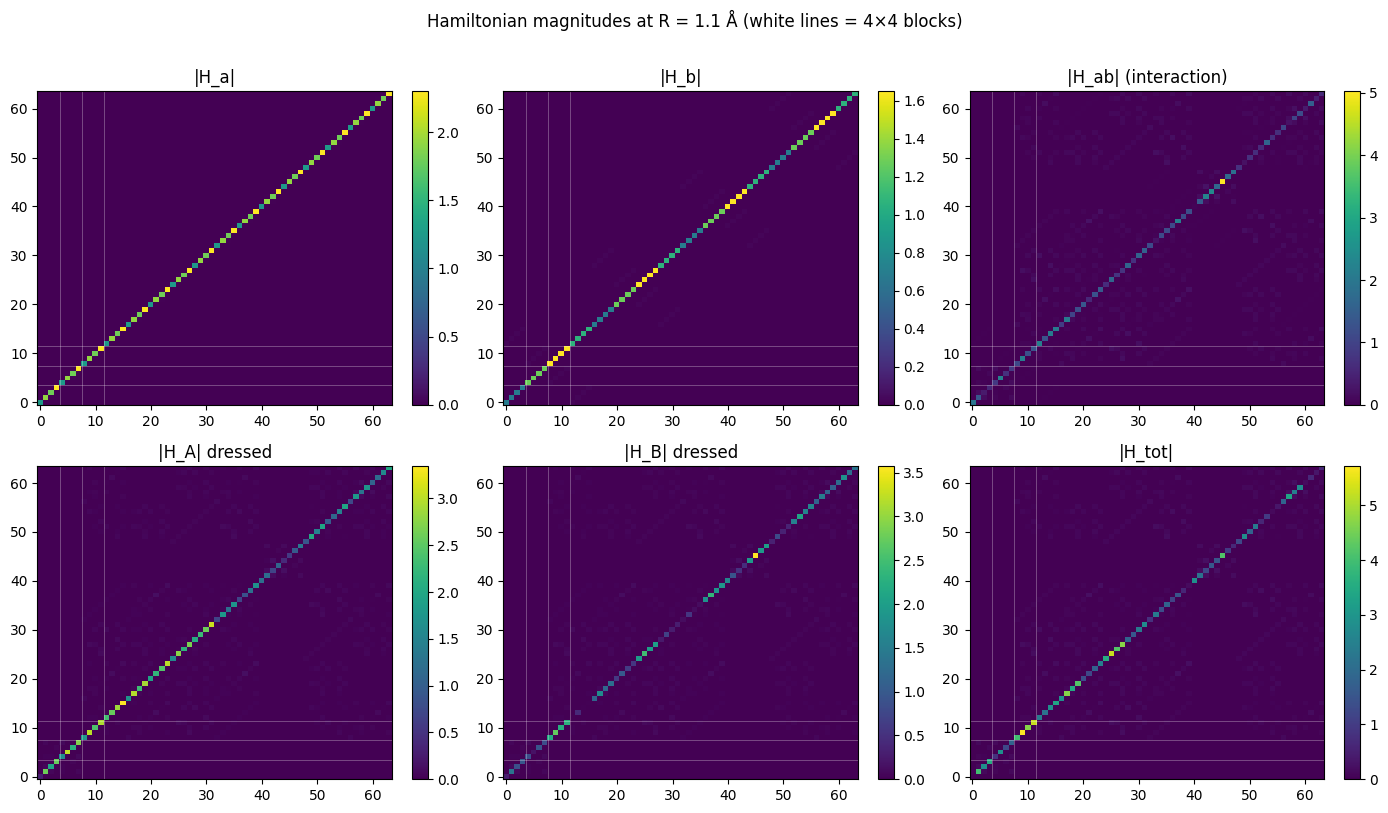

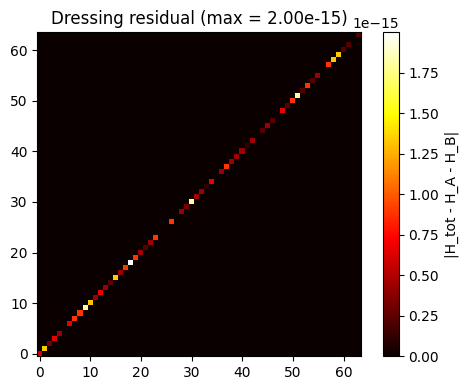


Saved -> output/krylov_interacting_sc_figures/step3b_H_matrices_R1p1.png, step3b_R1p1_hamiltonian.csv


In [10]:
# ── Step 3b: R = 1.1 Å — interaction Hamiltonian, dressed split, block norms ─
#
# Index convention on the 16-dim joint space (4 qubits, little-endian):
#   i = i_a + 4 * i_b   where i_a in {0..3} is molecule A, i_b is molecule B.
# Each 4x4 block H_block[i_b, j_b] has entries H[i_a + 4*i_b, j_a + 4*j_b].
#
# Schematic 2x2 fragment blocks (see markdown above):
#   H_tot ~ [[H_a, H_ab], [H_ab, H_b]] = H_A + H_B
#   H_A ~ [[H_a, H_ab/2], [H_ab/2, 0]],  H_B ~ [[0, H_ab/2], [H_ab/2, H_b]]

R_FOCUS = 1.1
D_MONO = 4   # STO-3G monomer Hilbert dimension after 2Q reduction

sys11 = systems[R_FOCUS]
H_a, H_b, H_ab = sys11['H_a'], sys11['H_b'], sys11['H_ab']
H_tot = sys11['H_tot']
H_A, H_B = sys11['H_A'], sys11['H_B']

# ── Algebraic checks (full 16x16 matrices) ───────────────────────────────────
res_partition = np.linalg.norm(H_tot - H_a - H_b - H_ab, ord='fro')
res_dressing  = np.linalg.norm(H_tot - H_A - H_B, ord='fro')

print('=' * 78)
print(f'R = {R_FOCUS} Å  |  E_exact(tot) = {sys11["gs_total"]:.8f} Ha')
print(f'  E_exact(a)+E_exact(b) = {sys11["E_exact_sum"]:.8f} Ha')
print(f'  Delta_exact (interaction shift) = {sys11["delta_exact"]:.6f} Ha')
print('=' * 78)
print('\n[Operator norms]')
for name, M in [('H_a', H_a), ('H_b', H_b), ('H_ab', H_ab),
                ('H_A = H_a + 1/2 H_ab', H_A), ('H_B = H_b + 1/2 H_ab', H_B),
                ('H_tot', H_tot)]:
    print(f'  {name:28s}  ||M||_2 = {np.linalg.norm(M, ord=2):10.6f}  '
          f'||M||_F = {np.linalg.norm(M, ord="fro"):10.6f}')

print(f'\n[Exact partition]  ||H_tot - H_a - H_b - H_ab||_F = {res_partition:.2e}')
print(f'[Dressing sum]     ||H_tot - H_A - H_B||_F           = {res_dressing:.2e}')
print(f'[Element-wise max] |H_tot - H_A - H_B|_max           = {np.max(np.abs(H_tot - H_A - H_B)):.2e}')
print('  -> (H_a, H_ab; H_ab, H_b) = (H_a, H_ab/2; H_ab/2, 0) + (0, H_ab/2; H_ab/2, H_b) exactly.')

print(f'\n[H_ab] {sys11["n_ab"]} cross-fragment Pauli terms. First few:')
for label, coeff in sys11['ab_sample']:
    print(f'    {label}  coeff = {coeff.real:+.6f}{coeff.imag:+.6f}j')


def extract_block(H, ib, jb):
    """4x4 block at B-indices (ib, jb); A indices run inside the block."""
    blk = np.zeros((D_MONO, D_MONO), dtype=complex)
    for ia in range(D_MONO):
        for ja in range(D_MONO):
            blk[ia, ja] = H[ia + D_MONO * ib, ja + D_MONO * jb]
    return blk


def pair_block_norm(H, ib_pair, jb_pair):
    """Frobenius norm of 8x8 super-block grouping two B basis indices."""
    n = len(ib_pair) * D_MONO
    blk = np.zeros((n, n), dtype=complex)
    for ii, ib in enumerate(ib_pair):
        for jj, jb in enumerate(jb_pair):
            sub = extract_block(H, ib, jb)
            blk[ii * D_MONO:(ii + 1) * D_MONO, jj * D_MONO:(jj + 1) * D_MONO] = sub
    return np.linalg.norm(blk, ord='fro')


# Schematic 2x2: group B indices (0,1) and (2,3) as two "sectors"
pairs = [(0, 1), (2, 3)]
schematic_labels = ['AA', 'AB', 'BA', 'BB']

print('\n[Schematic 2x2 super-block Frobenius norms]')
print(f'{"blk":>4}  {"||H_a||":>9}  {"||H_ab||":>9}  {"||H_b||":>9}  '
      f'{"||H_A||":>9}  {"||H_B||":>9}  {"||H_tot||":>9}  {"||H_A+H_B||":>9}')
for ri, ib_pair in enumerate(pairs):
    for ci, jb_pair in enumerate(pairs):
        tag = schematic_labels[ri * 2 + ci]
        nA = pair_block_norm(H_A, ib_pair, jb_pair)
        nB = pair_block_norm(H_B, ib_pair, jb_pair)
        print(f'{tag:>4}  {pair_block_norm(H_a, ib_pair, jb_pair):9.4f}  '
              f'{pair_block_norm(H_ab, ib_pair, jb_pair):9.4f}  '
              f'{pair_block_norm(H_b, ib_pair, jb_pair):9.4f}  '
              f'{nA:9.4f}  {nB:9.4f}  {pair_block_norm(H_tot, ib_pair, jb_pair):9.4f}  '
              f'{pair_block_norm(H_A + H_B, ib_pair, jb_pair):9.4f}')

# Per-block check: H_A block + H_B block = H_tot block (max over all 4x4 blocks)
max_blk_err = 0.0
for ib in range(D_MONO):
    for jb in range(D_MONO):
        err = np.linalg.norm(
            extract_block(H_tot, ib, jb) - extract_block(H_A, ib, jb) - extract_block(H_B, ib, jb))
        max_blk_err = max(max_blk_err, err)
print(f'\n[Per 4x4 block] max ||H_tot - H_A - H_B||_F over blocks = {max_blk_err:.2e}')

# ── Heatmaps of |H| on the 16x16 matrix ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
mats = [
    ('|H_a|', np.abs(H_a)), ('|H_b|', np.abs(H_b)), ('|H_ab| (interaction)', np.abs(H_ab)),
    ('|H_A| dressed', np.abs(H_A)), ('|H_B| dressed', np.abs(H_B)), ('|H_tot|', np.abs(H_tot)),
]
for ax, (title, M) in zip(axes.flat, mats):
    im = ax.imshow(M, origin='lower', aspect='auto', cmap='viridis')
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(title)
    for k in range(1, D_MONO):
        ax.axhline(k * D_MONO - 0.5, color='w', lw=0.4, alpha=0.5)
        ax.axvline(k * D_MONO - 0.5, color='w', lw=0.4, alpha=0.5)
fig.suptitle(f'Hamiltonian magnitudes at R = {R_FOCUS} Å (white lines = 4×4 blocks)', y=1.01)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/step3b_H_matrices_R1p1.png', dpi=150, bbox_inches='tight')
plt.show()

diff = np.abs(H_tot - H_A - H_B)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(diff, origin='lower', cmap='hot')
plt.colorbar(im, ax=ax, label='|H_tot - H_A - H_B|')
ax.set_title(f'Dressing residual (max = {diff.max():.2e})')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/step3b_dressing_residual_R1p1.png', dpi=150, bbox_inches='tight')
plt.show()

pd.DataFrame([{
    'R': R_FOCUS,
    'norm_H_a': float(np.linalg.norm(H_a, 2)),
    'norm_H_b': float(np.linalg.norm(H_b, 2)),
    'norm_H_ab': float(np.linalg.norm(H_ab, 2)),
    'norm_H_A': float(np.linalg.norm(H_A, 2)),
    'norm_H_B': float(np.linalg.norm(H_B, 2)),
    'norm_H_tot': float(np.linalg.norm(H_tot, 2)),
    'partition_residual': res_partition,
    'dressing_residual': res_dressing,
    'delta_exact': sys11['delta_exact'],
    'n_terms_ab': sys11['n_ab'],
}]).to_csv(f'{FIG_DIR}/step3b_R1p1_hamiltonian.csv', index=False)
print(f'\nSaved -> {FIG_DIR}/step3b_H_matrices_R1p1.png, step3b_R1p1_hamiltonian.csv')


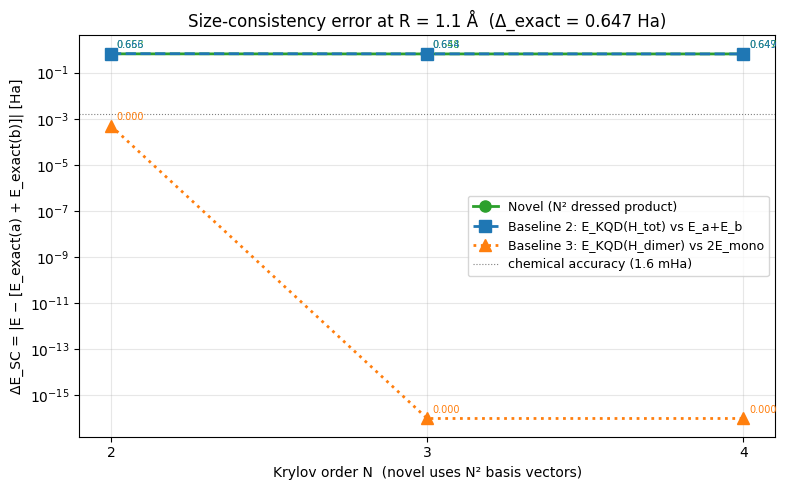

 N         procedure  basis_dim  gs_total   gs_err  delta_sc  delta_int
 2             novel          4 -1.621450 0.006066  0.653162        NaN
 2 baseline_separate          2 -1.608698 0.018818  0.665914   0.665914
 2    baseline_dimer          2 -1.608698 0.018818  0.000498   0.665417
 3             novel          9 -1.626642 0.000874  0.647970        NaN
 3 baseline_separate          3 -1.620927 0.006589  0.653685   0.653685
 3    baseline_dimer          3 -1.620927 0.006589  0.000000   0.653685
 4             novel         16 -1.627329 0.000187  0.647283        NaN
 4 baseline_separate          4 -1.626083 0.001433  0.648530   0.648530
 4    baseline_dimer          4 -1.626083 0.001433  0.000000   0.648530

Saved -> output/krylov_interacting_sc_figures/sc_error_vs_N_R1p1.png


In [11]:
# ── Step 3b: Size-consistency error vs N at R = 1.1 Å (all three procedures) ─
#
# delta_sc = |E_method - [E_exact(a) + E_exact(b)]|
# For Baseline 2 we use E_KQD(H_tot); for Baseline 3 we use E_KQD(H_dimer).
# The novel procedure uses the N^2 dressed product basis.

R_FOCUS = 1.1
sub11 = df_sweep[df_sweep['R'] == R_FOCUS].copy()

PROC_STYLE = {
    'novel': ('-', 'C2', 'o', 'Novel (N² dressed product)'),
    'baseline_separate': ('--', 'C0', 's', 'Baseline 2: E_KQD(H_tot) vs E_a+E_b'),
    'baseline_dimer': (':', 'C1', '^', 'Baseline 3: E_KQD(H_dimer) vs 2E_mono'),
}

fig, ax = plt.subplots(figsize=(8, 5))
for proc, (ls, c, mk, lbl) in PROC_STYLE.items():
    s = sub11[sub11['procedure'] == proc].sort_values('N')
    y = np.maximum(s['delta_sc'].values, 1e-16)
    ax.semilogy(s['N'], y, ls, color=c, marker=mk, ms=8, lw=2, label=lbl)
    for _, row in s.iterrows():
        ax.annotate(f'{row["delta_sc"]:.3f}', (row['N'], max(row['delta_sc'], 1e-16)),
                    textcoords='offset points', xytext=(4, 4), fontsize=7, color=c)

ax.axhline(1.6e-3, color='gray', ls=':', lw=0.8, label='chemical accuracy (1.6 mHa)')
ax.set_xlabel('Krylov order N  (novel uses N² basis vectors)')
ax.set_ylabel('ΔE_SC = |E − [E_exact(a) + E_exact(b)]| [Ha]')
ax.set_title(f'Size-consistency error at R = {R_FOCUS} Å  (Δ_exact = {systems[R_FOCUS]["delta_exact"]:.3f} Ha)')
ax.set_xticks(N_LIST)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/sc_error_vs_N_R1p1.png', dpi=150, bbox_inches='tight')
plt.show()

# Also save focused CSV
sub11.to_csv(f'{FIG_DIR}/step3b_sc_sweep_R1p1.csv', index=False)
print(sub11[['N', 'procedure', 'basis_dim', 'gs_total', 'gs_err', 'delta_sc', 'delta_int']].to_string(index=False))
print(f'\nSaved -> {FIG_DIR}/sc_error_vs_N_R1p1.png')


## Step 3c: Ground-state convergence at $R = 1.1$ Å — extended Krylov sweep

Joint Hilbert space dimension is **16**, so:

- **Novel:** $N^2$ basis vectors; $N=4$ saturates the space ($4^2=16$). We sweep $N \in \{2,\ldots,8\}$ to show convergence and overcomplete behaviour.
- **Baselines:** standard KQD on $H_\text{tot}$ with $N \in \{2,\ldots,16\}$ Krylov vectors.

Metric: $|E - E_\text{exact}(H_\text{tot})|$ vs Krylov dimension (plotted vs **basis size** for a fair comparison).

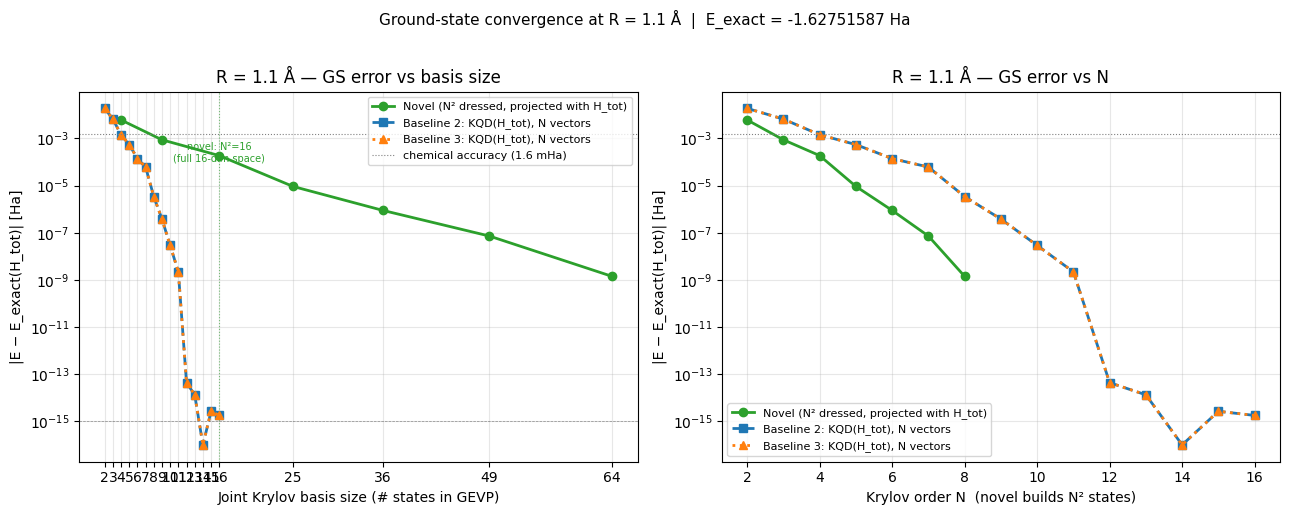

R = 1.1 Å  |  E_exact(H_tot) = -1.62751587 Ha  |  joint dim = 16

First basis_dim reaching chemical accuracy (1.6 mHa):
  novel                 basis_dim=  9  (N=3)  gs_err=8.74e-04 Ha  eff_dim=9
  baseline_separate     basis_dim=  4  (N=4)  gs_err=1.43e-03 Ha  eff_dim=4
  baseline_dimer        basis_dim=  4  (N=4)  gs_err=1.43e-03 Ha  eff_dim=4

Best gs_err per procedure:
  novel                 N= 8  basis_dim= 64  gs_err=1.41e-09 Ha  eff_dim=30
  baseline_separate     N=14  basis_dim= 14  gs_err=0.00e+00 Ha  eff_dim=12
  baseline_dimer        N=14  basis_dim= 14  gs_err=0.00e+00 Ha  eff_dim=12

Saved -> output/krylov_interacting_sc_figures/gs_error_convergence_R1p1.png
        output/krylov_interacting_sc_figures/step3c_gs_convergence_R1p1.csv


In [12]:
# ── Step 3c: Extended GS convergence sweep at R = 1.1 Å ───────────────────────
#
# Joint dim = 16.  Novel uses N² product states; baselines use N on H_tot.
# Plot gs_err vs basis_dim so all three procedures are comparable on one axis.

R_GS = 1.1
JOINT_DIM = 16
CHEM_ACC = 1.6e-3  # Ha

N_NOVEL_EXT = list(range(2, 9))       # N² = 4 .. 64 (redundant beyond N=4)
N_BASELINE_EXT = list(range(2, JOINT_DIM + 1))  # N = 2 .. 16

sys_gs = systems[R_GS]
E_exact = sys_gs['gs_total']

rows_gs = []

for N in N_NOVEL_EXT:
    rn = run_kqd_novel(sys_gs, N)
    rows_gs.append({
        'R': R_GS, 'N': N, 'procedure': 'novel',
        'basis_dim': N * N, 'eff_dim': rn['eff_dim'],
        'gs_total': rn['gs_total'], 'gs_err': rn['gs_err'],
        's_min': rn['s_min'],
    })

for N in N_BASELINE_EXT:
    b2 = run_baseline_separate(sys_gs, mono, N)
    rows_gs.append({
        'R': R_GS, 'N': N, 'procedure': 'baseline_separate',
        'basis_dim': N, 'eff_dim': b2['eff_dim'],
        'gs_total': b2['gs_total'], 'gs_err': b2['gs_err'],
        's_min': b2['s_min'],
    })
    b3 = run_baseline_dimer(sys_gs, N)
    rows_gs.append({
        'R': R_GS, 'N': N, 'procedure': 'baseline_dimer',
        'basis_dim': N, 'eff_dim': b3['eff_dim'],
        'gs_total': b3['gs_total'], 'gs_err': b3['gs_err'],
        's_min': b3['s_min'],
    })

df_gs11 = pd.DataFrame(rows_gs)
df_gs11.to_csv(f'{FIG_DIR}/step3c_gs_convergence_R1p1.csv', index=False)

# ── Plot: gs_err vs basis_dim (fair comparison) ───────────────────────────────
GS_STYLE = {
    'novel': ('-', 'C2', 'o', 'Novel (N² dressed, projected with H_tot)'),
    'baseline_separate': ('--', 'C0', 's', 'Baseline 2: KQD(H_tot), N vectors'),
    'baseline_dimer': (':', 'C1', '^', 'Baseline 3: KQD(H_tot), N vectors'),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: vs basis_dim (primary — comparable ansatz size)
ax = axes[0]
for proc, (ls, c, mk, lbl) in GS_STYLE.items():
    s = df_gs11[df_gs11['procedure'] == proc].sort_values('basis_dim')
    y = np.maximum(s['gs_err'].values, 1e-16)
    ax.semilogy(s['basis_dim'], y, ls, color=c, marker=mk, ms=6, lw=2, label=lbl)
    if proc == 'novel':
        ax.axvline(JOINT_DIM, color='C2', ls=':', lw=0.8, alpha=0.6)

ax.axhline(CHEM_ACC, color='gray', ls=':', lw=0.8, label='chemical accuracy (1.6 mHa)')
ax.axhline(1e-15, color='k', ls='--', lw=0.5, alpha=0.4)
ax.set_xlabel('Joint Krylov basis size (# states in GEVP)')
ax.set_ylabel('|E − E_exact(H_tot)| [Ha]')
ax.set_title(f'R = {R_GS} Å — GS error vs basis size')
ax.set_xticks(sorted(df_gs11['basis_dim'].unique()))
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc='upper right')
ax.annotate('novel: N²=16\n(full 16-dim space)', xy=(16, 1e-4), fontsize=7, color='C2', ha='center')

# Right: vs per-fragment N (procedure-native parameter)
ax = axes[1]
for proc, (ls, c, mk, lbl) in GS_STYLE.items():
    s = df_gs11[df_gs11['procedure'] == proc].sort_values('N')
    y = np.maximum(s['gs_err'].values, 1e-16)
    ax.semilogy(s['N'], y, ls, color=c, marker=mk, ms=6, lw=2, label=lbl)

ax.axhline(CHEM_ACC, color='gray', ls=':', lw=0.8)
ax.set_xlabel('Krylov order N  (novel builds N² states)')
ax.set_ylabel('|E − E_exact(H_tot)| [Ha]')
ax.set_title(f'R = {R_GS} Å — GS error vs N')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

fig.suptitle(
    f'Ground-state convergence at R = {R_GS} Å  |  E_exact = {E_exact:.8f} Ha',
    y=1.02, fontsize=11,
)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/gs_error_convergence_R1p1.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Convergence summary ─────────────────────────────────────────────────────
print(f'R = {R_GS} Å  |  E_exact(H_tot) = {E_exact:.8f} Ha  |  joint dim = {JOINT_DIM}')
print(f'\nFirst basis_dim reaching chemical accuracy ({CHEM_ACC*1e3:.1f} mHa):')
for proc in ['novel', 'baseline_separate', 'baseline_dimer']:
    sub = df_gs11[df_gs11['procedure'] == proc].sort_values('basis_dim')
    hit = sub[sub['gs_err'] < CHEM_ACC]
    if len(hit):
        row = hit.iloc[0]
        print(f'  {proc:20s}  basis_dim={int(row["basis_dim"]):3d}  (N={int(row["N"])})  '
              f'gs_err={row["gs_err"]:.2e} Ha  eff_dim={int(row["eff_dim"])}')
    else:
        best = sub.loc[sub['gs_err'].idxmin()]
        print(f'  {proc:20s}  NOT reached  best: basis_dim={int(best["basis_dim"])}  '
              f'gs_err={best["gs_err"]:.2e} Ha')

print(f'\nBest gs_err per procedure:')
for proc in ['novel', 'baseline_separate', 'baseline_dimer']:
    sub = df_gs11[df_gs11['procedure'] == proc]
    best = sub.loc[sub['gs_err'].idxmin()]
    print(f'  {proc:20s}  N={int(best["N"]):2d}  basis_dim={int(best["basis_dim"]):3d}  '
          f'gs_err={best["gs_err"]:.2e} Ha  eff_dim={int(best["eff_dim"])}')

print(f'\nSaved -> {FIG_DIR}/gs_error_convergence_R1p1.png')
print(f'        {FIG_DIR}/step3c_gs_convergence_R1p1.csv')

## Step 4: Interpretation checklist

| Criterion | What to check |
|---|---|
| Partition exact | $\|H_\text{tot} - H_a - H_b - H_{ab}\| < 10^{-10}$ |
| Dressing exact | $\|H_A + H_B - H_\text{tot}\| < 10^{-10}$ |
| Decoupling ($R=1000$ Å) | $\Delta_\text{SC}^\text{novel}(N{=}4) \to 0$ |
| SC vs baselines | Novel $\Delta_\text{SC}(N)$ below baselines at large $R$ |
| Interacting | Novel GS error converges faster in $N$ at small $R$ |


In [13]:
# ── Step 4: summary table, pass/fail checks, save step03_summary.csv ─────────

summary_rows = []
for R in sorted(systems.keys()):
    sub = df_sweep[(df_sweep['R'] == R) & (df_sweep['N'] == 4)]
    sys = systems[R]
    row = {
        'R': R,
        'delta_exact': sys['delta_exact'],
        'norm_H_ab': float(np.linalg.norm(sys['H_ab'], ord=2)),
        'partition_residual': sys['residual'],
        'dress_residual': sys['dress_residual'],
    }
    for proc in ['novel', 'baseline_separate', 'baseline_dimer']:
        s = sub[sub['procedure'] == proc]
        if len(s):
            row[f'gs_err_{proc}_N4'] = float(s['gs_err'].iloc[0])
            row[f'delta_sc_{proc}_N4'] = float(s['delta_sc'].iloc[0])
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(f'{FIG_DIR}/step03_summary.csv', index=False)

print('=' * 78)
print('INTERACTING SIZE-CONSISTENT KQD — SUMMARY')
print('=' * 78)

# Pass/fail at R=1000 A
R_dec = 1000.0
if R_dec in systems:
    sys = systems[R_dec]
    print(f'\n[Partition] residual = {sys["residual"]:.2e}  (expect < 1e-10)')
    print(f'[Dressing]  residual = {sys["dress_residual"]:.2e}  (expect < 1e-10)')
    sub4 = df_sweep[(df_sweep['R'] == R_dec) & (df_sweep['N'] == 4)]
    for proc in ['novel', 'baseline_separate', 'baseline_dimer']:
        sc = sub4[sub4['procedure'] == proc]['delta_sc'].iloc[0]
        ge = sub4[sub4['procedure'] == proc]['gs_err'].iloc[0]
        print(f'  R=1000 N=4 {proc:20s}  delta_sc={sc:.2e}  gs_err={ge:.2e}')
    sc_novel = sub4[sub4['procedure'] == 'novel']['delta_sc'].iloc[0]
    print(f'\nDecoupling PASS' if sc_novel < 1e-6 else f'\nDecoupling NOTE: novel delta_sc={sc_novel:.2e} at N=4')

print('\nBest delta_sc per (R, procedure) at max N:')
print(df_sweep.groupby(['R', 'procedure'])['delta_sc'].min().to_string())
print('\nBest gs_err per (R, procedure) at max N:')
print(df_sweep.groupby(['R', 'procedure'])['gs_err'].min().to_string())
print(f'\nAll outputs -> {FIG_DIR}/')
print(df_summary.to_string(index=False))


INTERACTING SIZE-CONSISTENT KQD — SUMMARY

[Partition] residual = 1.55e-15  (expect < 1e-10)
[Dressing]  residual = 1.78e-15  (expect < 1e-10)
  R=1000 N=4 novel                 delta_sc=1.51e-14  gs_err=1.78e-15
  R=1000 N=4 baseline_separate     delta_sc=1.51e-14  gs_err=1.78e-15
  R=1000 N=4 baseline_dimer        delta_sc=1.78e-15  gs_err=1.78e-15

Decoupling PASS

Best delta_sc per (R, procedure) at max N:
R       procedure        
1.1     baseline_dimer       0.000000e+00
        baseline_separate    6.485296e-01
        novel                6.472828e-01
10.0    baseline_dimer       8.881784e-16
        baseline_separate    1.236458e-07
        novel                1.278792e-07
100.0   baseline_dimer       8.881784e-16
        baseline_separate    2.042810e-12
        novel                2.043254e-12
1000.0  baseline_dimer       0.000000e+00
        baseline_separate    1.509903e-14
        novel                8.881784e-16

Best gs_err per (R, procedure) at max N:
R       proced